# Resume DeBERTa-v3-base LoRA Training after Kaggle Timeout

The first DeBERTa run exceeded the Kaggle session limit, so this notebook continues it from the saved `BackupAndRestore` state. The model, optimizer step, learning-rate schedule, checkpoints, and training log all need to match the interrupted run.

As before, labels use `0..4` during training and are converted back to `1..5` for evaluation.

## Kaggle setup

1. Enable a GPU accelerator in Notebook settings.
2. Add the same processed dataset used by the interrupted run.
3. Recommended offline-safe setup: choose **Add Input → Models**, search for `keras/deberta_v3`, and attach the Keras model `deberta_v3_base_en` before starting `Save & Run All`. The notebook automatically discovers its local preset under `/kaggle/input`.
4. If no local model is attached, enable Internet so KerasHub can resolve the built-in `deberta_v3_base_en` preset.
5. Attach the published output of the timed-out run containing `deberta_v3_keras_lora/training_backup`.
6. If discovery is ambiguous, set `KAGGLE_DATASET_SLUG`, `LOCAL_MODEL_PRESET`, or `RESUME_SOURCE_DIR` explicitly.

The notebook auto-discovers the attached `train.csv` and `validation.csv`; the recommended dataset is `bert_balanced_50000_per_class` (240,000 train and 10,000 validation rows).

In [1]:
import os
import shutil
import subprocess
import sys

os.environ['KERAS_BACKEND'] = 'tensorflow'

try:
    import keras_hub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-hub'])
    import keras_hub

import keras
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('KerasHub:', keras_hub.__version__)
print('scikit-learn:', sklearn.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
KerasHub: 0.26.0
scikit-learn: 1.6.1


## Configuration — change paths or experiment settings only here

In [2]:
from pathlib import Path

# Use the attached Kaggle model when available; otherwise use Hugging Face.
MODEL_PRESET = 'deberta_v3_base_en'
LOCAL_MODEL_PRESET = '/kaggle/input/models/keras/deberta_v3/keras/deberta_v3_base_en/3'  # Attached Kaggle preset.
NUM_CLASSES = 5
MAX_LENGTH = 256  # Preserve substantially more review evidence than 128 tokens.
EPOCHS = 4  # Must match the interrupted run; BackupAndRestore resumes within epoch 3.
PER_REPLICA_BATCH_SIZE = 8  # Reduce to 4 only if DeBERTa-v3-base exhausts P100 memory.
USE_MULTI_GPU = False  # Keep False for TF 2.20 + KerasHub 0.26 LoRA stability.
LORA_RANK = 16
PEAK_LEARNING_RATE = 4.5e-5  # Matches Microsoft's DeBERTa-v3 small/base fine-tuning range.
END_LEARNING_RATE_RATIO = 0.10
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01
RANDOM_STATE = 42
CHECKPOINT_EVERY_BATCHES = 500

# Set this only when more than one matching dataset is attached.
KAGGLE_DATASET_SLUG = 'datasets/maslri/balanced-50000/bert_balanced_50000_per_class'
# Optional path to the attached timed-out output's deberta_v3_keras_lora folder.
RESUME_SOURCE_DIR = '/kaggle/input/notebooks/alisalari76/notebook933a068a79'

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/deberta_v3_keras_lora')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
BACKUP_DIR = OUTPUT_DIR / 'training_backup'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [OUTPUT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

## Restore the interrupted run into writable storage

Kaggle input folders are read-only, but Keras needs to update the backup while training. This step finds the attached output from the timed-out run and copies its backup, checkpoints, and logs into `/kaggle/working`. If the metadata or latest weights are missing, the run should stop here.

In [3]:
def find_artifact_roots(search_root):
    search_root = Path(search_root)
    if not search_root.exists():
        raise FileNotFoundError(search_root)

    # The attached output may contain another folder level, so find the
    # backup marker instead of relying on one fixed path.
    metadata_files = list(search_root.rglob('training_metadata.json'))
    return sorted({
        metadata_path.parent.parent
        for metadata_path in metadata_files
        if metadata_path.parent.name == 'training_backup'
        and (metadata_path.parent / 'latest.weights.h5').exists()
    })

def resolve_resume_source():
    search_root = Path(RESUME_SOURCE_DIR) if RESUME_SOURCE_DIR else INPUT_ROOT
    candidates = find_artifact_roots(search_root)
    preferred = [
        path for path in candidates
        if path.name == 'deberta_v3_keras_lora'
    ]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) != 1:
        raise FileNotFoundError(
            f'Expected one resumable DeBERTa artifact under {search_root}; '
            f'found {candidates}. Set RESUME_SOURCE_DIR to the folder that '
            'contains deberta_v3_keras_lora or to that folder itself.'
        )
    return candidates[0]

RESUME_SOURCE = resolve_resume_source()
assert RESUME_SOURCE.resolve() != OUTPUT_DIR.resolve()
print('Resume source:', RESUME_SOURCE)

for folder_name in ['training_backup', 'checkpoints', 'logs']:
    source = RESUME_SOURCE / folder_name
    destination = OUTPUT_DIR / folder_name
    if source.exists():
        shutil.copytree(source, destination, dirs_exist_ok=True)
        print(f'Copied {folder_name}: {source} -> {destination}')

resume_metadata_path = BACKUP_DIR / 'training_metadata.json'
resume_weights_path = BACKUP_DIR / 'latest.weights.h5'
assert resume_metadata_path.exists(), resume_metadata_path
assert resume_weights_path.exists(), resume_weights_path
assert (CHECKPOINT_DIR / 'best.weights.h5').exists()
assert (CHECKPOINT_DIR / 'latest.weights.h5').exists()

import json
resume_metadata = json.loads(resume_metadata_path.read_text(encoding='utf-8'))
print('Backup metadata:', resume_metadata)
print('Resume state copy: PASSED')

Resume source: /kaggle/input/notebooks/alisalari76/notebook933a068a79/deberta_v3_keras_lora
Copied training_backup: /kaggle/input/notebooks/alisalari76/notebook933a068a79/deberta_v3_keras_lora/training_backup -> /kaggle/working/deberta_v3_keras_lora/training_backup
Copied checkpoints: /kaggle/input/notebooks/alisalari76/notebook933a068a79/deberta_v3_keras_lora/checkpoints -> /kaggle/working/deberta_v3_keras_lora/checkpoints
Copied logs: /kaggle/input/notebooks/alisalari76/notebook933a068a79/deberta_v3_keras_lora/logs -> /kaggle/working/deberta_v3_keras_lora/logs
Backup metadata: {'epoch': 2, 'batch': 6499}
Resume state copy: PASSED


## GPU, mixed precision, and distributed strategy

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError('No GPU detected. Enable a Kaggle GPU accelerator before training.')

keras.mixed_precision.set_global_policy('mixed_float16')

# TF 2.20 + KerasHub 0.26 can fail with a bool AddN reduction when
# PipelineModel/LoRA is trained under MirroredStrategy on Kaggle T4x2.
# The default strategy reliably uses GPU:0 without cross-replica reduction.
if USE_MULTI_GPU:
    strategy = tf.distribute.MirroredStrategy()
else:
    strategy = tf.distribute.get_strategy()
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync

print('GPUs:', gpus)
print('Strategy:', type(strategy).__name__)
print('Replicas:', strategy.num_replicas_in_sync)
print('Global batch size:', GLOBAL_BATCH_SIZE)
print('Mixed precision policy:', keras.mixed_precision.global_policy())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Strategy: _DefaultDistributionStrategy
Replicas: 1
Global batch size: 8
Mixed precision policy: <DTypePolicy "mixed_float16">


## Locate and validate the Kaggle dataset

In [5]:
def find_dataset_file(filename):
    search_root = INPUT_ROOT / KAGGLE_DATASET_SLUG if KAGGLE_DATASET_SLUG else INPUT_ROOT
    candidates = sorted(search_root.rglob(filename))
    valid_candidates = []
    for path in candidates:
        try:
            columns = pd.read_csv(path, nrows=2).columns
            if {'overall', 'model_input'}.issubset(columns):
                valid_candidates.append(path)
        except Exception:
            continue
    if len(valid_candidates) != 1:
        raise FileNotFoundError(
            f'Expected exactly one valid {filename}; found {valid_candidates}. '
            'Set KAGGLE_DATASET_SLUG explicitly.'
        )
    return valid_candidates[0]

TRAIN_PATH = find_dataset_file('train.csv')
VALIDATION_PATH = find_dataset_file('validation.csv')
print('Train:', TRAIN_PATH)
print('Validation:', VALIDATION_PATH)

Train: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/train.csv
Validation: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/validation.csv


In [6]:
usecols = ['overall', 'model_input']
train_df = pd.read_csv(TRAIN_PATH, usecols=usecols, low_memory=False)
validation_df = pd.read_csv(VALIDATION_PATH, usecols=usecols, low_memory=False)

for name, frame in [('train', train_df), ('validation', validation_df)]:
    assert frame['overall'].between(1, 5).all(), f'Invalid labels in {name}'
    assert frame['model_input'].notna().all(), f'Missing text in {name}'
    assert frame['model_input'].str.strip().ne('').all(), f'Empty text in {name}'
    print(name, frame.shape, frame['overall'].value_counts().sort_index().to_dict())

train_text = train_df['model_input'].astype(str).to_numpy()
validation_text = validation_df['model_input'].astype(str).to_numpy()
train_labels = (train_df['overall'].to_numpy(dtype='int32') - 1)
validation_labels = (validation_df['overall'].to_numpy(dtype='int32') - 1)

train (240000, 2) {1: 48000, 2: 48000, 3: 48000, 4: 48000, 5: 48000}
validation (10000, 2) {1: 2000, 2: 2000, 3: 2000, 4: 2000, 5: 2000}


## Build the `tf.data` pipeline

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
options = tf.data.Options()
options.experimental_deterministic = True

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_text, train_labels))
    .shuffle(len(train_text), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    .batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
    .with_options(options)
)
validation_ds = (
    tf.data.Dataset.from_tensor_slices((validation_text, validation_labels))
    .batch(GLOBAL_BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .with_options(options)
)

STEPS_PER_EPOCH = len(train_text) // GLOBAL_BATCH_SIZE
TOTAL_STEPS = STEPS_PER_EPOCH * EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_RATIO))
DECAY_STEPS = max(1, TOTAL_STEPS - WARMUP_STEPS)
print({
    'steps_per_epoch': STEPS_PER_EPOCH,
    'total_steps': TOTAL_STEPS,
    'warmup_steps': WARMUP_STEPS,
    'decay_steps': DECAY_STEPS,
})

I0000 00:00:1785918831.269005      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


{'steps_per_epoch': 30000, 'total_steps': 120000, 'warmup_steps': 12000, 'decay_steps': 108000}


## DeBERTa-v3-base PEFT/LoRA, AdamW, warmup, and cosine decay

The model definition must stay identical to the original run: DeBERTa-v3-base, rank-16 LoRA, sequence length 256, and the same optimizer schedule. Changing any of these would make the copied optimizer state unreliable.

Validation micro-F1 is used for checkpoint selection, while macro and weighted F1 are calculated after training.

In [8]:
learning_rate = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0,
    warmup_target=PEAK_LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    decay_steps=DECAY_STEPS,
    alpha=END_LEARNING_RATE_RATIO,
)

def resolve_deberta_preset():
    if LOCAL_MODEL_PRESET:
        local_path = Path(LOCAL_MODEL_PRESET)
        if not (local_path / 'config.json').exists():
            raise FileNotFoundError(f'No config.json in LOCAL_MODEL_PRESET={local_path}')
        return str(local_path)

    local_candidates = []
    for config_path in INPUT_ROOT.rglob('config.json'):
        candidate = config_path.parent
        candidate_text = str(candidate).lower()
        if 'deberta' in candidate_text:
            local_candidates.append(candidate)

    local_candidates = sorted(set(local_candidates))
    if len(local_candidates) == 1:
        print('Using attached offline Kaggle Model preset.')
        return str(local_candidates[0])
    if len(local_candidates) > 1:
        raise RuntimeError(
            f'Multiple local DeBERTa presets found: {local_candidates}. '
            'Set LOCAL_MODEL_PRESET explicitly.'
        )

    import socket
    try:
        socket.gethostbyname('huggingface.co')
    except OSError as error:
        raise RuntimeError(
            'No attached DeBERTa-v3 preset was found and Kaggle Internet/DNS is disabled. '
            'Use Add Input -> Models -> keras/deberta_v3 -> deberta_v3_base_en, '
            'then restart and run the notebook again.'
        ) from error
    print('No local preset found; using the online Hugging Face fallback.')
    return MODEL_PRESET

effective_model_preset = resolve_deberta_preset()
print('Loading preset:', effective_model_preset)

with strategy.scope():
    model = keras_hub.models.DebertaV3TextClassifier.from_preset(
        effective_model_preset,
        num_classes=NUM_CLASSES,
        activation=None,
        dropout=0.1,
    )
    model.preprocessor.sequence_length = MAX_LENGTH
    model.backbone.enable_lora(rank=LORA_RANK)

    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=WEIGHT_DECAY,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-6,
        global_clipnorm=1.0,
    )
    optimizer.exclude_from_weight_decay(var_names=['bias', 'beta', 'gamma'])
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='micro_f1')],
        jit_compile=False,
    )

trainable_params = int(sum(np.prod(variable.shape) for variable in model.trainable_weights))
total_params = int(sum(np.prod(variable.shape) for variable in model.weights))
trainable_pct = 100.0 * trainable_params / total_params

print(f'Trainable parameters: {trainable_params:,}')
print(f'Total parameters: {total_params:,}')
print(f'Trainable percentage: {trainable_pct:.4f}%')
model.summary()

Loading preset: /kaggle/input/models/keras/deberta_v3/keras/deberta_v3_base_en/3
Trainable parameters: 4,176,389
Total parameters: 187,989,509
Trainable percentage: 2.2216%


Preprocessor: "deberta_v3_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ deberta_v3_tokenizer (DebertaV3Tokenizer)                     │                      Vocab size: 128,001 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "deberta_v3_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deberta_v3_backbone           │ (None, None, 768)         │     187,395,072 │ padding_mask[0][0],        │
│ (DebertaV3Backbone)           │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ deberta_v3_backbone[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 5)                 │           3,845 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 187,989,509 (717.12 MB)

 Trainable params: 4,176,389 (15.93 MB)

 Non-trainable params: 183,813,120 (701.19 MB)

## Resume checkpoints

When `fit()` starts, `BackupAndRestore` should pick up the copied batch-level state. I also read the previous best validation score from `training.csv` so a weaker resumed epoch cannot overwrite `best.weights.h5`. Early stopping is left out here because only the remaining part of the scheduled run needs to finish.

- `training_backup/`: resumable training state; automatically restored when the same notebook is rerun.
- `latest.weights.h5`: emergency periodic weights.
- `best.weights.h5`: best epoch by validation micro F1.
- `deberta_v3_lora_adapters.lora.h5`: compact final LoRA adapter weights from the backbone.

The resumed output still needs to be saved or downloaded before the Kaggle session is discarded.

In [9]:
training_log_path = LOG_DIR / 'training.csv'
if training_log_path.exists() and training_log_path.stat().st_size > 0:
    previous_history = pd.read_csv(training_log_path)
    if 'val_micro_f1' in previous_history.columns:
        previous_best_val_micro_f1 = float(previous_history['val_micro_f1'].max())
    else:
        previous_best_val_micro_f1 = None
else:
    previous_best_val_micro_f1 = None
print('Previous best validation micro F1:', previous_best_val_micro_f1)

callbacks = [
    keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR),
        save_freq=CHECKPOINT_EVERY_BATCHES,
        double_checkpoint=True,
        delete_checkpoint=False,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'latest.weights.h5'),
        save_weights_only=True,
        save_freq=CHECKPOINT_EVERY_BATCHES,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINT_DIR / 'best.weights.h5'),
        monitor='val_micro_f1',
        mode='max',
        save_best_only=True,
        save_weights_only=True,
        initial_value_threshold=previous_best_val_micro_f1,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(str(LOG_DIR / 'training.csv'), append=True),
    keras.callbacks.TensorBoard(log_dir=str(LOG_DIR / 'tensorboard'), update_freq=100),
    keras.callbacks.TerminateOnNaN(),
]

Previous best validation micro F1: 0.6729999780654907


## Train

At the start of this cell, Keras should continue inside epoch 3 instead of printing epoch 1. The backup is refreshed every 500 batches. Based on the speed of the interrupted run, the remaining training time is roughly 9.5 hours.

In [10]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 3/4


2026-08-05 08:34:09.498232: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


  499/30000 ━━━━━━━━━━━━━━━━━━━━ 5:13:20 637ms/step - loss: 0.7993 - micro_f1: 0.6514
Epoch 3: saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5

Epoch 3: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 5:11:33 645ms/step - loss: 0.7940 - micro_f1: 0.6565
Epoch 3: saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5

Epoch 3: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 5:07:18 647ms/step - loss: 0.7899 - micro_f1: 0.6592
Epoch 3: saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5

Epoch 3: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5
 1999/30000 ━━━━━━━━━━━━━━━━━━━━ 5:02:01 647ms/step - loss: 0.7862 - micro_f1: 0.6609
Epoch 3: saving model to /kaggle/working/deberta_v3_keras_lora/check

2026-08-05 13:57:27.403495: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_11}}



Epoch 3: val_micro_f1 improved from 0.67300 to 0.67580, saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/best.weights.h5

Epoch 3: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 19572s 651ms/step - loss: 0.7584 - micro_f1: 0.6755 - val_loss: 0.7751 - val_micro_f1: 0.6758
Epoch 4/4
  499/30000 ━━━━━━━━━━━━━━━━━━━━ 5:10:08 631ms/step - loss: 0.7445 - micro_f1: 0.6739
Epoch 4: saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5

Epoch 4: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5
  999/30000 ━━━━━━━━━━━━━━━━━━━━ 5:10:11 642ms/step - loss: 0.7450 - micro_f1: 0.6774
Epoch 4: saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5

Epoch 4: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/latest.weights.h5
 1499/30000 ━━━━━━━━━━━━━━━━━━━━ 5:05:04 642ms/step - loss:

2026-08-05 19:23:42.416092: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_11}}



Epoch 4: val_micro_f1 improved from 0.67580 to 0.67590, saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/best.weights.h5

Epoch 4: finished saving model to /kaggle/working/deberta_v3_keras_lora/checkpoints/best.weights.h5
30000/30000 ━━━━━━━━━━━━━━━━━━━━ 19574s 652ms/step - loss: 0.7507 - micro_f1: 0.6787 - val_loss: 0.7721 - val_micro_f1: 0.6759


## Evaluate the best checkpoint

In [11]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

best_weights_path = CHECKPOINT_DIR / 'best.weights.h5'
if best_weights_path.exists():
    model.load_weights(best_weights_path)

validation_logits = model.predict(validation_ds, verbose=1)
validation_prediction_zero_based = np.argmax(validation_logits, axis=1)
validation_prediction = validation_prediction_zero_based + 1
validation_truth = validation_labels + 1

metrics = {
    'accuracy': accuracy_score(validation_truth, validation_prediction),
    'micro_f1': f1_score(validation_truth, validation_prediction, average='micro'),
    'macro_f1': f1_score(validation_truth, validation_prediction, average='macro'),
    'weighted_f1': f1_score(validation_truth, validation_prediction, average='weighted'),
}
print(metrics)
print(classification_report(validation_truth, validation_prediction, digits=4))

2026-08-05 19:26:59.413671: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_11}}


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 174s 133ms/step
{'accuracy': 0.6757, 'micro_f1': 0.6757, 'macro_f1': 0.6737844649728075, 'weighted_f1': 0.6737844649728074}
              precision    recall  f1-score   support

           1     0.7166    0.7725    0.7435      2000
           2     0.5803    0.5350    0.5567      2000
           3     0.6031    0.6010    0.6021      2000
           4     0.6646    0.6480    0.6562      2000
           5     0.7992    0.8220    0.8105      2000

    accuracy                         0.6757     10000
   macro avg     0.6728    0.6757    0.6738     10000
weighted avg     0.6728    0.6757    0.6738     10000



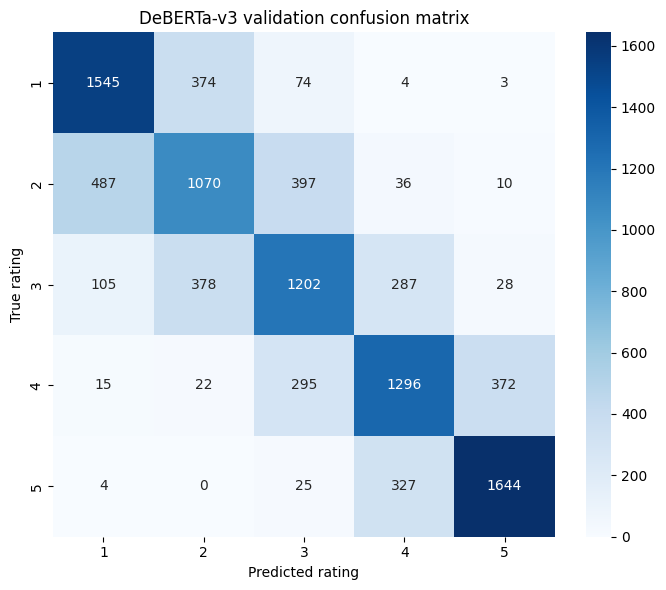

118

In [12]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

matrix = confusion_matrix(validation_truth, validation_prediction, labels=[1, 2, 3, 4, 5])
plt.figure(figsize=(7, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted rating')
plt.ylabel('True rating')
plt.title('DeBERTa-v3 validation confusion matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=160)
plt.show()

pd.DataFrame({
    'true_rating': validation_truth,
    'predicted_rating': validation_prediction,
}).to_csv(OUTPUT_DIR / 'validation_predictions.csv', index=False)

(OUTPUT_DIR / 'validation_metrics.json').write_text(
    json.dumps(metrics, indent=2) + '\n', encoding='utf-8'
)

## Save the trained model

In [13]:
# KerasHub only recognizes adapters with the `.lora.h5` suffix.
model.backbone.save_lora_weights(OUTPUT_DIR / 'deberta_v3_lora_adapters.lora.h5')
model.save(OUTPUT_DIR / 'deberta_v3_rating_classifier.keras')
model.save_to_preset(OUTPUT_DIR / 'deberta_v3_rating_classifier_preset')

parameter_stats = {
    'lora_rank': LORA_RANK,
    'trainable_parameters': trainable_params,
    'total_parameters': total_params,
    'trainable_percentage': trainable_pct,
}
(OUTPUT_DIR / 'parameter_stats.json').write_text(
    json.dumps(parameter_stats, indent=2) + '\n', encoding='utf-8'
)

print('Artifacts:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(OUTPUT_DIR), f'{path.stat().st_size / 1024**2:.2f} MB')

Artifacts:
checkpoints/best.weights.h5 767.81 MB
checkpoints/latest.weights.h5 767.81 MB
confusion_matrix.png 0.06 MB
deberta_v3_lora_adapters.lora.h5 13.66 MB
deberta_v3_rating_classifier.keras 770.16 MB
deberta_v3_rating_classifier_preset/assets/tokenizer/vocabulary.spm 2.35 MB
deberta_v3_rating_classifier_preset/config.json 0.00 MB
deberta_v3_rating_classifier_preset/metadata.json 0.00 MB
deberta_v3_rating_classifier_preset/model.weights.h5 701.69 MB
deberta_v3_rating_classifier_preset/preprocessor.json 0.00 MB
deberta_v3_rating_classifier_preset/task.json 0.00 MB
deberta_v3_rating_classifier_preset/task.weights.h5 767.81 MB
deberta_v3_rating_classifier_preset/tokenizer.json 0.00 MB
logs/tensorboard/train/events.out.tfevents.1785865242.4f00aa37811b.23.0.v2 9.10 MB
logs/tensorboard/train/events.out.tfevents.1785918846.62f8225a82e2.24.0.v2 8.21 MB
logs/tensorboard/validation/events.out.tfevents.1785884591.4f00aa37811b.23.1.v2 0.00 MB
logs/tensorboard/validation/events.out.tfevents.178

## Notes

- Select the final checkpoint using validation micro-F1 and inspect the class-level scores as well.
- Do not make tuning decisions from the official test predictions.
- If memory becomes a problem, lower the batch size before changing the input length.
- Compare the completed DeBERTa run with RoBERTa only when preprocessing and validation data are identical.